# Credit Card Fraud Detection EDA

In [10]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

df = pd.read_csv("creditcard.csv")
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")

Shape: (13954, 31)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [11]:
# Cell 2 — Basic info (screenshot this)
print("=== DATA TYPES ===")
print(df.dtypes)
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())
print("\n=== CLASS DISTRIBUTION ===")
print(df['Class'].value_counts())
print(f"\nFraud percentage: {df['Class'].mean()*100:.4f}%")

=== DATA TYPES ===
Time        int64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class     float64
dtype: object

=== MISSING VALUES ===
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    1
Class     1
dtype: int64


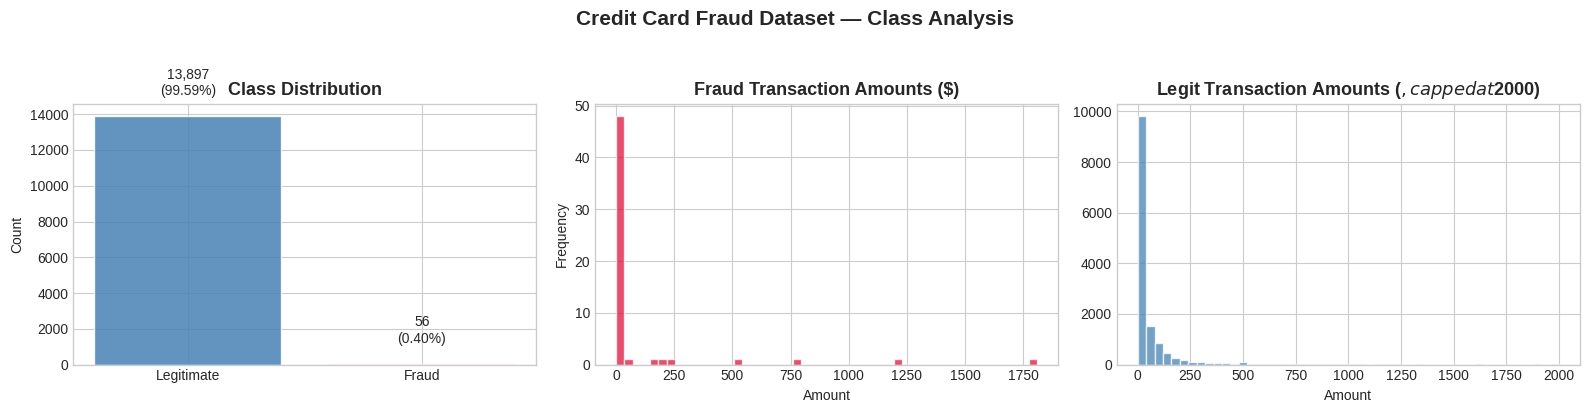

Saved: class_distribution.png


In [12]:
# Cell 3 — Class imbalance plot (SCREENSHOT THIS — hero image for README)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: Class counts
counts = df['Class'].value_counts()
bars = axes[0].bar(['Legitimate', 'Fraud'], counts.values,
                    color=['steelblue', 'crimson'], alpha=0.85, edgecolor='white')
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                f'{count:,}\n({count/len(df)*100:.2f}%)',
                ha='center', va='bottom', fontsize=10)

# Plot 2: Fraud transaction amounts
df[df['Class']==1]['Amount'].hist(ax=axes[1], bins=50,
                                   color='crimson', alpha=0.75, edgecolor='white')
axes[1].set_title('Fraud Transaction Amounts ($)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Frequency')

# Plot 3: Legit transaction amounts (capped for visibility)
df[df['Class']==0]['Amount'].clip(upper=2000).hist(ax=axes[2], bins=50,
                                                    color='steelblue', alpha=0.75, edgecolor='white')
axes[2].set_title('Legit Transaction Amounts ($, capped at $2000)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Amount')

plt.suptitle('Credit Card Fraud Dataset — Class Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: class_distribution.png")

In [13]:
# Cell 4 — Statistical summary (screenshot this too)
print("=== FRAUD TRANSACTIONS ===")
print(df[df['Class']==1]['Amount'].describe().round(2))
print("\n=== LEGITIMATE TRANSACTIONS ===")
print(df[df['Class']==0]['Amount'].describe().round(2))

=== FRAUD TRANSACTIONS ===
count      56.00
mean       90.82
std       310.31
min         0.00
25%         1.00
50%         1.00
75%         1.02
max      1809.68
Name: Amount, dtype: float64

=== LEGITIMATE TRANSACTIONS ===
count    13897.00
mean        63.77
std        177.16
min          0.00
25%          5.77
50%         15.90
75%         52.37
max       7712.43
Name: Amount, dtype: float64


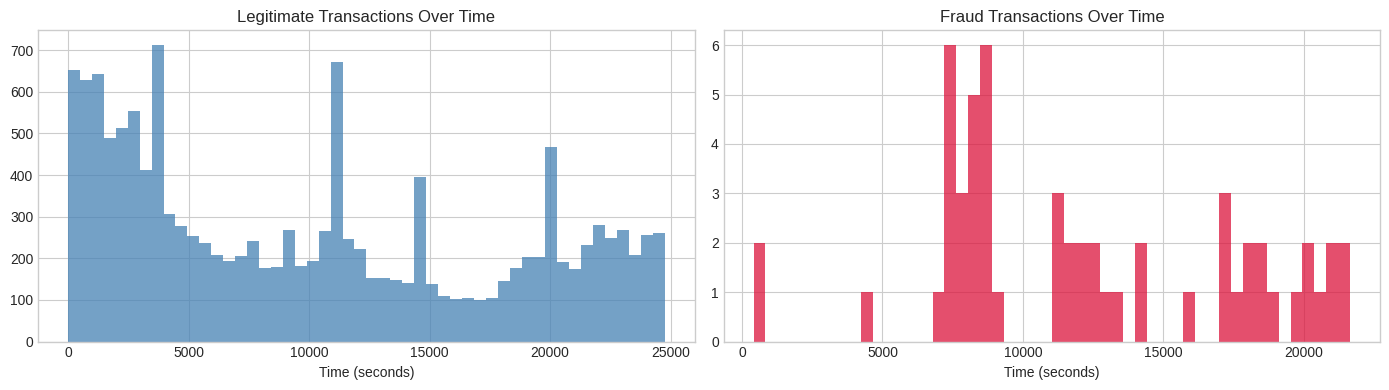

In [14]:
# Cell 5 — Time distribution (shows fraud happens at different times)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df[df['Class']==0]['Time'].hist(ax=axes[0], bins=50,
                                 color='steelblue', alpha=0.75)
axes[0].set_title('Legitimate Transactions Over Time')
axes[0].set_xlabel('Time (seconds)')

df[df['Class']==1]['Time'].hist(ax=axes[1], bins=50,
                                 color='crimson', alpha=0.75)
axes[1].set_title('Fraud Transactions Over Time')
axes[1].set_xlabel('Time (seconds)')

plt.tight_layout()
plt.savefig("time_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

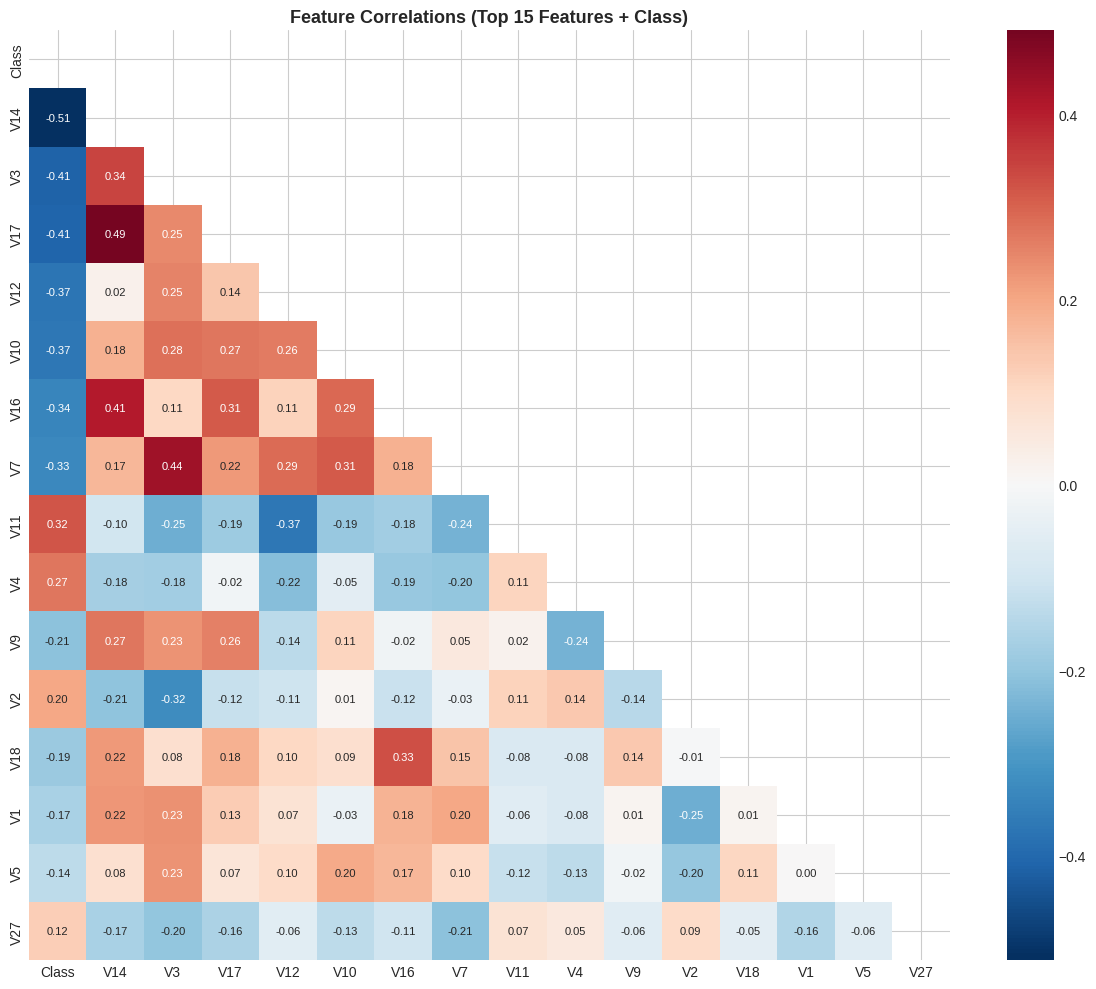

In [15]:
# Cell 6 — Correlation heatmap of top features with Class
# This shows which PCA features are most predictive
correlations = df.corrwith(df['Class']).abs().sort_values(ascending=False)
top_features = correlations.head(16).index.tolist()  # Class + top 15

fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df[top_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax,
            annot_kws={"size": 8})
ax.set_title('Feature Correlations (Top 15 Features + Class)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

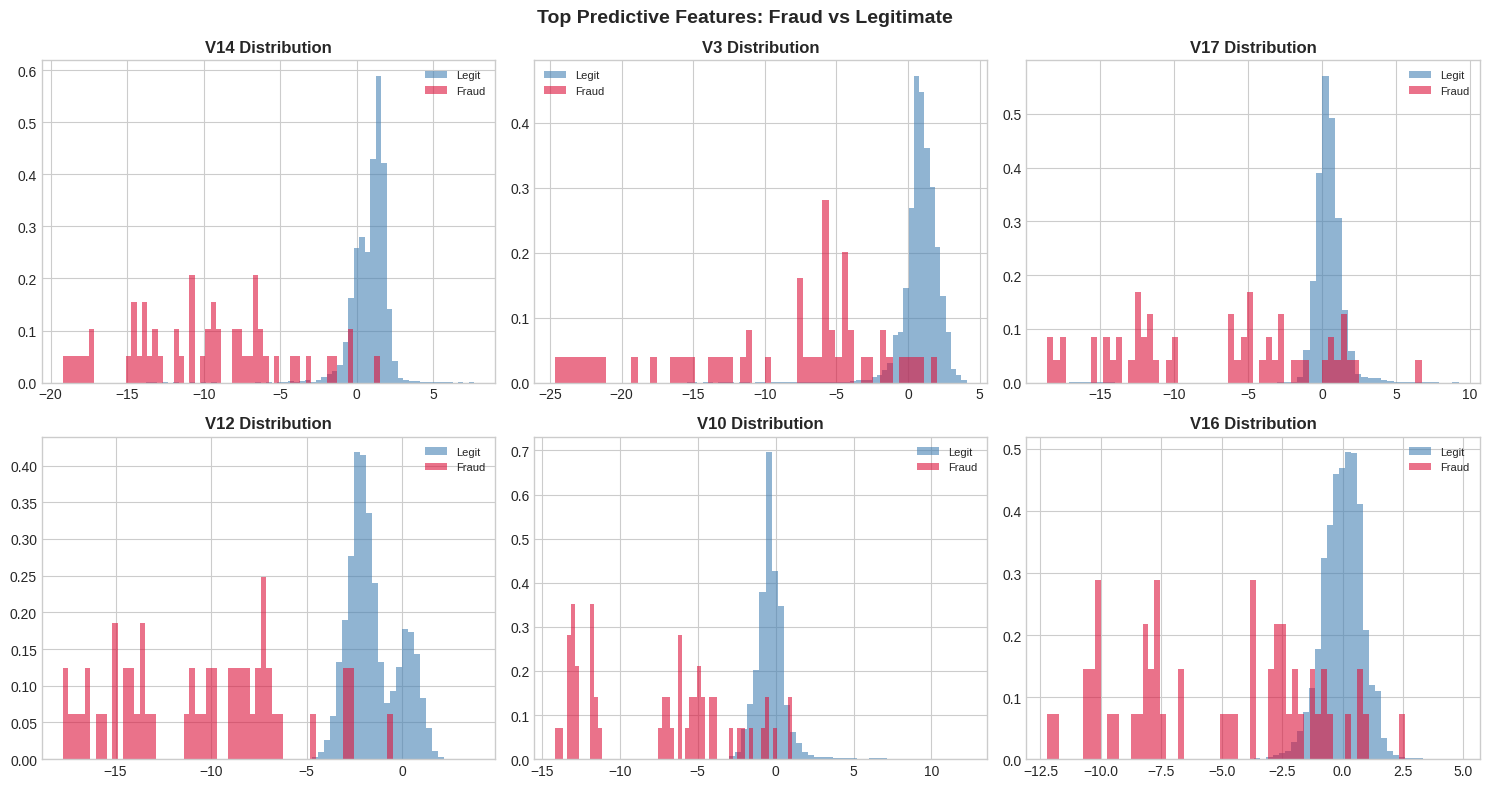

These are the features your model will rely on most heavily.


In [16]:
# Cell 7 — Feature distributions: Fraud vs Legit for top 6 features
top_v_features = correlations[1:7].index.tolist()  # skip Class itself

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(top_v_features):
    axes[i].hist(df[df['Class']==0][feature], bins=60,
                 alpha=0.6, color='steelblue', label='Legit', density=True)
    axes[i].hist(df[df['Class']==1][feature], bins=60,
                 alpha=0.6, color='crimson', label='Fraud', density=True)
    axes[i].set_title(f'{feature} Distribution', fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Top Predictive Features: Fraud vs Legitimate',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print("These are the features your model will rely on most heavily.")

In [17]:
# Cell 8 — Download all plots to your computer
from google.colab import files

for fname in ["class_distribution.png", "time_distribution.png",
              "correlation_heatmap.png", "feature_distributions.png"]:
    files.download(fname)

print("Download these 4 images — they go into your README")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download these 4 images — they go into your README


In [18]:
# Cell 9 — Also download the CSV so you can use it locally
# (or just keep the one you downloaded from Kaggle)
print("Key stats to remember for your README:")
print(f"Total transactions: {len(df):,}")
print(f"Fraud cases: {df['Class'].sum():,}")
print(f"Fraud rate: {df['Class'].mean()*100:.4f}%")
print(f"Max fraud amount: ${df[df['Class']==1]['Amount'].max():.2f}")
print(f"Avg fraud amount: ${df[df['Class']==1]['Amount'].mean():.2f}")
print(f"Avg legit amount: ${df[df['Class']==0]['Amount'].mean():.2f}")

Key stats to remember for your README:
Total transactions: 13,954
Fraud cases: 56.0
Fraud rate: 0.4013%
Max fraud amount: $1809.68
Avg fraud amount: $90.82
Avg legit amount: $63.77
